In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
import sys
import os
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

## The objective of this notebook is to understand how Minutes work
### What leads to a players minutes
- Role
- Health/status
- opponent matchup
- game script (spread, pace, blowout risk)
- coach tendencies
- recent performance


In [2]:
# s25 = pd.read_csv('data/raw/season_stats/s25.csv')
# s26 = pd.read_csv('data/raw/season_stats/s26.csv')
s25 = pd.read_csv('data/processed/training/PTS_TRAIN_25.csv')
s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv')

df = pd.concat([s25, s26])
df['MIN'] = pd.to_numeric(df['MIN'], errors='coerce')
df.sample(5)

C:\Users\alexg\AppData\Local\Temp\ipykernel_33744\4249645297.py:4: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv')


,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,...,OFF_RATING,DEF_RATING,matchupFieldGoalsPercentage,matchupThreePointersPercentage,BLK_y,TEAM_SEASON_ID,TEAM_GAME_DATE,TEAM_MATCHUP,TEAM_WL,VIDEO_AVAILABLE
17776,NaN,NaN,NaN,17776,Tidjane Salaün,1642275,CHA @ LAL,CHA,1610612766,LAL,...,100.0,0.0,0.000,0.000,0.0,22025.0,2026-01-15,CHA @ LAL,W,1.0
9757,NaN,NaN,NaN,9757,Brandon Williams,1630314,DAL vs. UTA,DAL,1610612742,UTA,...,124.6,103.4,0.636,0.333,1.0,22025.0,2026-01-15,DAL vs. UTA,W,1.0
18360,NaN,NaN,NaN,18360,Keshad Johnson,1642352,MIA @ BOS,MIA,1610612748,BOS,...,300.0,0.0,0.000,0.000,0.0,22025.0,2025-12-19,MIA @ BOS,L,1.0
11096,11096.0,23912.0,23912.0,23912,De'Andre Hunter,1629631,CLE vs. LAC,CLE,1610612739,LAC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9728,NaN,NaN,NaN,9728,Brandon Williams,1630314,DAL @ MEM,DAL,1610612742,MEM,...,100.0,91.8,0.200,0.000,0.0,22025.0,2025-11-07,DAL @ MEM,L,1.0


In [3]:
def buildFeatures(df):
    df = df.sort_values('GAME_DATE').copy()
    df['MIN'] = pd.to_numeric(df['MIN'], errors='coerce')

    out = []

    for player in df['PLAYER_NAME'].unique():
        pdf = df[df['PLAYER_NAME'] == player].copy()

        pdf['MIN_LAG_1'] = pdf['MIN'].shift(1)
        pdf['MIN_ROLLING_3'] = pdf['MIN'].shift(1).rolling(3).mean().round(2)
        pdf['MIN_ROLLING_5'] = pdf['MIN'].shift(1).rolling(5).mean().round(2)
        pdf['MIN_ROLLING_7'] = pdf['MIN'].shift(1).rolling(7).mean().round(2)
        pdf['MIN_ROLLING_10'] = pdf['MIN'].shift(1).rolling(10).mean().round(2)

        pdf['MEDIAN_ROLLING_3'] = pdf['MIN'].shift(1).rolling(3).median().round(2)
        pdf['MEDIAN_ROLLING_7'] = pdf['MIN'].shift(1).rolling(7).median().round(2)
        pdf['MEDIAN_ROLLING_10'] = pdf['MIN'].shift(1).rolling(10).median().round(2)

        pdf['STD_ROLLING_3'] = pdf['MIN'].shift(1).rolling(3).std().round(2)
        pdf['STD_ROLLING_7'] = pdf['MIN'].shift(1).rolling(7).std().round(2)
        pdf['STD_ROLLING_10'] = pdf['MIN'].shift(1).rolling(10).std().round(2)        

        pdf['STARTING'] = pdf['START_POSITION'].notna().astype(int)
        pdf['STARTING_X_MIN'] = pdf['STARTING'] * pdf['MIN_AVG_TO_DATE']
        
        out.append(pdf)
    return pd.concat(out, axis=0).sort_index()

df = buildFeatures(df)

df['TEAM_ROLE_RANK'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_ROLLING_5'].rank(ascending=False, method='dense'))
df['MIN_TREND_3'] = df['MIN_LAG_1'] - df['MIN_ROLLING_7']
df['MIN_VOLATILITY'] = df['STD_ROLLING_7'] / df['MIN_ROLLING_7']

df.tail()

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,...,MEDIAN_ROLLING_3,MEDIAN_ROLLING_7,MEDIAN_ROLLING_10,STD_ROLLING_3,STD_ROLLING_7,STD_ROLLING_10,STARTING_X_MIN,TEAM_ROLE_RANK,MIN_TREND_3,MIN_VOLATILITY
26301,26301.0,15786.0,15786.0,15786,Yuki Kawamura,1642530,MEM vs. SAS,MEM,1610612763,SAS,...,2.30,2.30,2.76,5.09,3.49,3.36,0.0,11.0,-1.67,0.920844
26302,26302.0,16198.0,16198.0,16198,Yuki Kawamura,1642530,MEM @ TOR,MEM,1610612763,TOR,...,2.12,2.12,2.21,0.13,3.54,3.07,0.0,13.0,-1.57,0.977901
26303,26303.0,17343.0,17343.0,17343,Yuki Kawamura,1642530,MEM @ LAC,MEM,1610612763,LAC,...,2.12,2.30,2.76,0.92,3.40,2.90,0.0,11.0,-0.28,0.860759
26304,26304.0,25629.0,25629.0,25629,Yuki Kawamura,1642530,MEM vs. MIN,MEM,1610612763,MIN,...,2.05,2.12,2.21,1.37,3.50,3.01,0.0,14.0,-2.38,1.051051
26305,26305.0,26078.0,26078.0,26078,Yuki Kawamura,1642530,MEM vs. DAL,MEM,1610612763,DAL,...,1.47,2.12,2.08,1.44,3.48,3.07,0.0,8.0,-1.90,1.032641


In [4]:
def testMetrics(df):
    temp = df[[
            'MIN',
            'MIN_LAG_1',
            'MIN_ROLLING_3',
            'MIN_ROLLING_7',
            'MIN_ROLLING_10',
            'MEDIAN_ROLLING_3',
            'MEDIAN_ROLLING_7',
            'MEDIAN_ROLLING_10']].dropna()

    rmsePrev = math.sqrt(mean_squared_error(temp['MIN'], temp['MIN_LAG_1']))
    rmseRolling3 = math.sqrt(mean_squared_error(temp['MIN'], temp['MIN_ROLLING_3']))
    rmseRolling5 = math.sqrt(mean_squared_error(temp['MIN'], temp['MIN_ROLLING_7']))
    rmseRolling10 = math.sqrt(mean_squared_error(temp['MIN'], temp['MIN_ROLLING_10']))
    rmseMedian3 = math.sqrt(mean_squared_error(temp['MIN'], temp['MEDIAN_ROLLING_3']))
    rmseMedian5 = math.sqrt(mean_squared_error(temp['MIN'], temp['MEDIAN_ROLLING_7']))
    rmseMedian10 = math.sqrt(mean_squared_error(temp['MIN'], temp['MEDIAN_ROLLING_10']))

    print("Previous game RMSE:", rmsePrev)
    print("Rolling 3 avg RMSE:", rmseRolling3)
    print("Rolling 7 avg RMSE:", rmseRolling5)
    print("Rolling 10 avg RMSE:", rmseRolling10)
    print("Median 3 avg RMSE:", rmseMedian3)
    print("Median 7 avg RMSE:", rmseMedian5)
    print("Median 10 avg RMSE:", rmseMedian10)

testMetrics(df)

Previous game RMSE: 7.937491366691977
Rolling 3 avg RMSE: 6.870850554898515
Rolling 7 avg RMSE: 6.728068663985863
Rolling 10 avg RMSE: 6.778273373017985
Median 3 avg RMSE: 7.142507390552946
Median 7 avg RMSE: 6.991864763401819
Median 10 avg RMSE: 6.990841052526631


In [5]:
df = df[df['MIN'] > 20]
print(f"Length of new dataset is {len(df)}")

Length of new dataset is 28821


In [ ]:
target = 'MIN'
features = ['STARTING', 'PLAYER_DAYS_REST', 'IS_BACK_TO_BACK',
            'MIN_ROLLING_7', 'MIN_ROLLING_10', 
            'MEDIAN_ROLLING_3', 'MEDIAN_ROLLING_7', 'MEDIAN_ROLLING_10', 
            'STARTING_X_MIN', 'TEAM_ROLE_RANK', 'MIN_TREND_3', 'MIN_VOLATILITY']

In [7]:
from sklearn.linear_model import LinearRegression

df = df[[target] + features].dropna()

X = df[features]
y = df[target]

split_index = int(len(df) * 0.75)
x_train = X.iloc[:split_index]
x_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

lr_pred = lr_model.predict(x_test)

print("R2:", r2_score(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("MAE: ", mean_absolute_error(y_test, lr_pred))

R2: 0.3213893146398077
RMSE: 4.479610364459256
MAE:  3.5526505619200415


In [8]:
importance = pd.Series(lr_model.coef_, index=features)
importance = importance.sort_values(key=abs, ascending=False)

print(importance)

MIN_VOLATILITY       13.436707
STARTING             -1.468331
STD_ROLLING_7        -0.497530
TEAM_ROLE_RANK       -0.274701
IS_BACK_TO_BACK      -0.216661
MIN_ROLLING_10        0.171804
STARTING_X_MIN        0.165449
STD_ROLLING_10        0.124893
HOME_GAME            -0.120514
PLAYER_DAYS_REST     -0.103613
MIN_ROLLING_7         0.091965
MIN_LAG_1             0.067132
MIN_ROLLING_3         0.044323
MEDIAN_ROLLING_10    -0.038636
MEDIAN_ROLLING_7      0.036139
MIN_TREND_3          -0.024833
MEDIAN_ROLLING_3      0.024359
STD_ROLLING_3         0.020517
dtype: float64


In [9]:
from sklearn.ensemble import RandomForestRegressor

df = df[[target] + features].dropna()

X = df[features]
y = df[target]

split_index = int(len(df) * 0.75)
x_train = X.iloc[:split_index]
x_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
rf_model = RandomForestRegressor(
n_estimators=200,
max_depth=20,
min_samples_split=5,
random_state=42,
n_jobs=-1
)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

print("R2:", r2_score(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred) ** 0.5)
print("MAE: ", mean_absolute_error(y_test, rf_pred))

R2: 0.4101648824285101
RMSE: 4.375513280529256
MAE:  3.477062118809529


In [10]:
importance = pd.Series(rf_model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

STARTING_X_MIN       0.416383
MIN_ROLLING_10       0.064942
MIN_ROLLING_3        0.062576
MIN_ROLLING_7        0.058992
STD_ROLLING_3        0.044541
MEDIAN_ROLLING_10    0.043953
MEDIAN_ROLLING_3     0.043105
MEDIAN_ROLLING_7     0.040351
STD_ROLLING_10       0.040284
MIN_LAG_1            0.040115
MIN_TREND_3          0.037734
MIN_VOLATILITY       0.030249
STD_ROLLING_7        0.027917
TEAM_ROLE_RANK       0.024478
PLAYER_DAYS_REST     0.015525
HOME_GAME            0.004634
IS_BACK_TO_BACK      0.002581
STARTING             0.001639
dtype: float64


In [11]:
from xgboost import XGBRegressor

df = df[[target] + features].dropna()

X = df[features]
y = df[target]

split_index = int(len(df) * 0.75)
x_train = X.iloc[:split_index]
x_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
xgb_model = XGBRegressor(
n_estimators=400,
learning_rate=0.05,
max_depth=6,
subsample=0.8,
colsample_bytree=0.8,
random_state=42,
n_jobs=-1
)
xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)

print("R2:", r2_score(y_test, xgb_pred))
print("RMSE:", mean_squared_error(y_test, xgb_pred) ** 0.5)
print("MAE: ", mean_absolute_error(y_test, xgb_pred))

R2: 0.41547394607442867
RMSE: 4.355776927947602
MAE:  3.458717428203345


In [12]:
importance = pd.Series(xgb_model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

STARTING_X_MIN       0.284446
STARTING             0.282212
MIN_ROLLING_7        0.063172
MIN_ROLLING_10       0.060788
TEAM_ROLE_RANK       0.047078
MIN_ROLLING_3        0.028537
MEDIAN_ROLLING_3     0.025356
MEDIAN_ROLLING_10    0.023435
MEDIAN_ROLLING_7     0.022673
MIN_VOLATILITY       0.021981
MIN_TREND_3          0.021503
STD_ROLLING_10       0.020445
MIN_LAG_1            0.018613
STD_ROLLING_7        0.018436
STD_ROLLING_3        0.018350
PLAYER_DAYS_REST     0.016888
HOME_GAME            0.015610
IS_BACK_TO_BACK      0.010477
dtype: float32


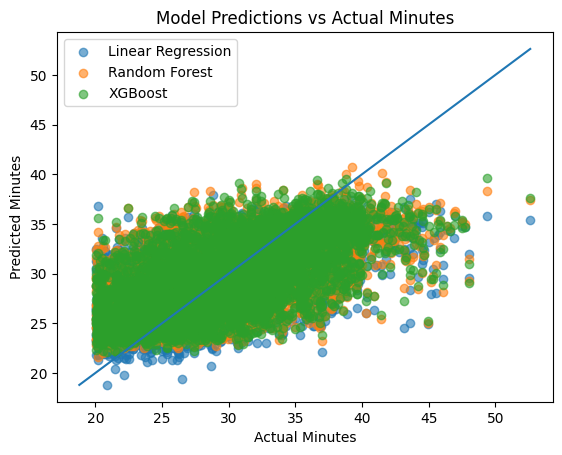

Linear Regression RMSE: 4.410353957586947
Random Forest RMSE: 4.375513280529256
XGBoost RMSE: 4.355776927947602


In [13]:
lr_pred = lr_model.predict(x_test)
rf_pred = rf_model.predict(x_test)

plt.scatter(y_test, lr_pred, label="Linear Regression", alpha=0.6)
plt.scatter(y_test, rf_pred, label="Random Forest", alpha=0.6)
plt.scatter(y_test, xgb_pred, label='XGBoost', alpha=0.6)

min_val = min(y_test.min(), lr_pred.min(), rf_pred.min())
max_val = max(y_test.max(), lr_pred.max(), rf_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Minutes")
plt.ylabel("Predicted Minutes")
plt.title("Model Predictions vs Actual Minutes")
plt.legend()

plt.show()

print("Linear Regression RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("Random Forest RMSE:", mean_squared_error(y_test, rf_pred) ** 0.5)
print("XGBoost RMSE:", mean_squared_error(y_test, xgb_pred) ** 0.5)